In [7]:
import joblib
import numpy as np

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
X_train = joblib.load(r"D:\tensor_titan\data\processed\X_train.pkl")
X_test = joblib.load(r"D:\tensor_titan\data\processed\X_test.pkl")

y_train = joblib.load(r"D:\tensor_titan\data\processed\y_train.pkl")
y_test = joblib.load(r"D:\tensor_titan\data\processed\y_test.pkl")

In [9]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nNB Classification Report:\n", classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.6892853753440258

NB Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.60      0.66       768
           1       0.92      0.45      0.60       556
           2       0.55      0.75      0.64      3081
           3       0.81      0.88      0.84      3269
           4       1.00      0.08      0.15       215
           5       0.73      0.08      0.14       517
           6       0.70      0.62      0.66      2131

    accuracy                           0.69     10537
   macro avg       0.78      0.49      0.53     10537
weighted avg       0.72      0.69      0.67     10537



In [10]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nNB Classification Report:\n", classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.6892853753440258

NB Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.60      0.66       768
           1       0.92      0.45      0.60       556
           2       0.55      0.75      0.64      3081
           3       0.81      0.88      0.84      3269
           4       1.00      0.08      0.15       215
           5       0.73      0.08      0.14       517
           6       0.70      0.62      0.66      2131

    accuracy                           0.69     10537
   macro avg       0.78      0.49      0.53     10537
weighted avg       0.72      0.69      0.67     10537



In [11]:
lr_model = LogisticRegression(
    max_iter=300,
    class_weight='balanced'
)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nLR Classification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7679605200721268

LR Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.79      0.78       768
           1       0.72      0.82      0.77       556
           2       0.81      0.61      0.69      3081
           3       0.90      0.92      0.91      3269
           4       0.50      0.74      0.60       215
           5       0.50      0.70      0.59       517
           6       0.68      0.76      0.72      2131

    accuracy                           0.77     10537
   macro avg       0.70      0.76      0.72     10537
weighted avg       0.78      0.77      0.77     10537



In [12]:
svm_model = LinearSVC(class_weight='balanced')

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nSVM Classification Report:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.7764069469488469

SVM Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.79      0.77       768
           1       0.77      0.80      0.78       556
           2       0.76      0.67      0.71      3081
           3       0.90      0.94      0.92      3269
           4       0.64      0.67      0.65       215
           5       0.56      0.61      0.58       517
           6       0.68      0.72      0.70      2131

    accuracy                           0.78     10537
   macro avg       0.72      0.74      0.73     10537
weighted avg       0.78      0.78      0.77     10537



In [13]:
print("\n=== MODEL COMPARISON ===")
print("Naive Bayes:", accuracy_score(y_test, y_pred_nb))
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("SVM:", accuracy_score(y_test, y_pred_svm))


=== MODEL COMPARISON ===
Naive Bayes: 0.6892853753440258
Logistic Regression: 0.7679605200721268
SVM: 0.7764069469488469


In [14]:
models = {
    "Naive Bayes": (nb_model, y_pred_nb),
    "Logistic Regression": (lr_model, y_pred_lr),
    "SVM": (svm_model, y_pred_svm)
}

best_model_name = None
best_model = None
best_score = 0

for name, (model, preds) in models.items():
    score = accuracy_score(y_test, preds)
    if score > best_score:
        best_score = score
        best_model_name = name
        best_model = model

print(f"\nBest Model: {best_model_name} with accuracy {best_score}")


Best Model: SVM with accuracy 0.7764069469488469


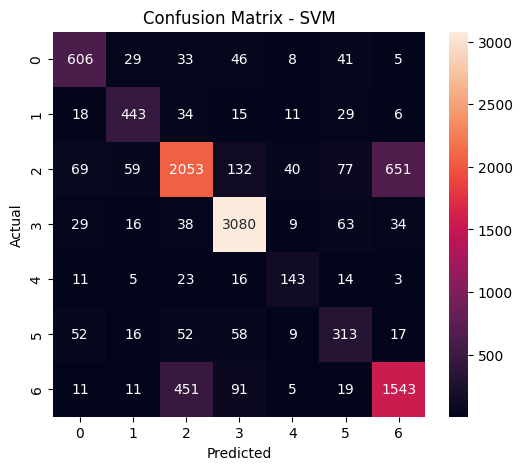

In [15]:
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [16]:
joblib.dump(best_model, r"D:\tensor_titan\models\best_model.pkl")

['D:\\tensor_titan\\models\\best_model.pkl']